In [20]:
from tensorflow.keras.models import load_model
import joblib

model = load_model("models/energy_lstm_model.keras")
scaler = joblib.load("models/scaler.save")

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 30, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 91,955 (359.20 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 61,304 (239.47 KB)

In [21]:
import pandas as pd

# load dataset
df = pd.read_csv(
    "household_power_consumption.txt",
    sep=";",
    low_memory=False,
    na_values=["?"]
)

print(df.head())

         Date      Time  Global_active_power  Global_reactive_power  Voltage  \
0  16/12/2006  17:24:00                4.216                  0.418   234.84   
1  16/12/2006  17:25:00                5.360                  0.436   233.63   
2  16/12/2006  17:26:00                5.374                  0.498   233.29   
3  16/12/2006  17:27:00                5.388                  0.502   233.74   
4  16/12/2006  17:28:00                3.666                  0.528   235.68   

   Global_intensity  Sub_metering_1  Sub_metering_2  Sub_metering_3  
0              18.4             0.0             1.0            17.0  
1              23.0             0.0             1.0            16.0  
2              23.0             0.0             2.0            17.0  
3              23.0             0.0             1.0            17.0  
4              15.8             0.0             1.0            17.0  


In [22]:
df.isna().sum()

Date                         0
Time                         0
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64

In [23]:
df["datetime"] = pd.to_datetime(df["Date"] + " " + df["Time"])

df = df.set_index("datetime")

df["Global_active_power"] = pd.to_numeric(df["Global_active_power"], errors="coerce")

df = df.dropna()

C:\Users\anush\AppData\Local\Temp\ipykernel_32912\191425056.py:1: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["datetime"] = pd.to_datetime(df["Date"] + " " + df["Time"])


In [24]:
daily_power = df["Global_active_power"].resample("D").mean()

print(daily_power.head())

datetime
2006-12-16    3.053475
2006-12-17    2.354486
2006-12-18    1.530435
2006-12-19    1.157079
2006-12-20    1.545658
Freq: D, Name: Global_active_power, dtype: float64


In [32]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(daily_power.values.reshape(-1,1))

In [33]:
import numpy as np

# take last 30 days from dataset
last_30_days = scaled_data[-30:]

# reshape for LSTM
last_30_days = last_30_days.reshape(1, 30, 1)

In [27]:
pred_scaled = model.predict(last_30_days)
print(pred_scaled)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step
[[nan]]


In [34]:
future_predictions = []

current_input = scaled_data[-30:]

for i in range(30):

    current_input_reshaped = current_input.reshape(1,30,1)

    pred = model.predict(current_input_reshaped)

    future_predictions.append(pred[0][0])

    current_input = np.append(current_input[1:], pred)

future_predictions = scaler.inverse_transform(
    np.array(future_predictions).reshape(-1,1)
)

print(future_predictions)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━

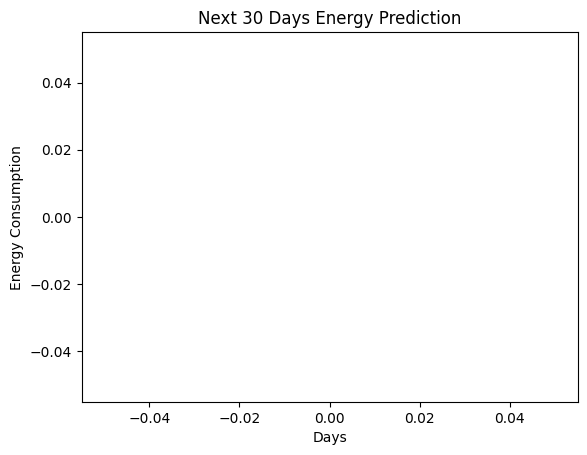

In [35]:
import matplotlib.pyplot as plt

plt.plot(future_predictions)
plt.title("Next 30 Days Energy Prediction")
plt.xlabel("Days")
plt.ylabel("Energy Consumption")
plt.show()

In [36]:
import numpy as np

print(last_30_days.shape)
print(np.isnan(last_30_days).sum())
print(np.isinf(last_30_days).sum())
print(last_30_days[:5])

(1, 30, 1)
0
0
[[[0.26818581]
  [0.21094527]
  [0.42059805]
  [0.27108294]
  [0.2504665 ]
  [0.20799595]
  [0.23059467]
  [0.50957399]
  [0.32849018]
  [0.34381599]
  [0.3147226 ]
  [0.34826694]
  [0.39172353]
  [0.37501724]
  [0.33678186]
  [0.35076125]
  [0.39196142]
  [0.39532594]
  [0.33098715]
  [0.27844915]
  [0.29443027]
  [0.30993295]
  [0.29185857]
  [0.43039357]
  [0.14384244]
  [0.39602104]
  [0.29343625]
  [0.34179083]
  [0.26107518]
  [0.31977106]]]
